In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
import astropy.units as u
from astropy.constants import sigma_sb, R_sun, L_sun

In [2]:
df = pd.read_csv(r'/kaggle/input/nasa-exoplanet-archive/PS_2025.08.14_09.21.47_dataset.csv')

## EDA

In [3]:
print(f"Head:\n{df.head()}\n\nShape:\n{df.shape}\n\nUnique Values:\n{df.nunique()}")

Head:
    pl_name hostname  default_flag  sy_snum  sy_pnum  discoverymethod  \
0  11 Com b   11 Com             1        2        1  Radial Velocity   
1  11 Com b   11 Com             0        2        1  Radial Velocity   
2  11 Com b   11 Com             0        2        1  Radial Velocity   
3  11 UMi b   11 UMi             0        1        1  Radial Velocity   
4  11 UMi b   11 UMi             0        1        1  Radial Velocity   

   disc_year                           disc_facility              soltype  \
0       2007                        Xinglong Station  Published Confirmed   
1       2007                        Xinglong Station  Published Confirmed   
2       2007                        Xinglong Station  Published Confirmed   
3       2009  Thueringer Landessternwarte Tautenburg  Published Confirmed   
4       2009  Thueringer Landessternwarte Tautenburg  Published Confirmed   

   pl_controv_flag  ... sy_vmagerr2  sy_kmag  sy_kmagerr1  sy_kmagerr2  \
0                0

## Readability

In [4]:
# Identify why so many columns are used
print(df.columns)

Index(['pl_name', 'hostname', 'default_flag', 'sy_snum', 'sy_pnum',
       'discoverymethod', 'disc_year', 'disc_facility', 'soltype',
       'pl_controv_flag', 'pl_refname', 'pl_orbper', 'pl_orbpererr1',
       'pl_orbpererr2', 'pl_orbperlim', 'pl_orbsmax', 'pl_orbsmaxerr1',
       'pl_orbsmaxerr2', 'pl_orbsmaxlim', 'pl_rade', 'pl_radeerr1',
       'pl_radeerr2', 'pl_radelim', 'pl_radj', 'pl_radjerr1', 'pl_radjerr2',
       'pl_radjlim', 'pl_bmasse', 'pl_bmasseerr1', 'pl_bmasseerr2',
       'pl_bmasselim', 'pl_bmassj', 'pl_bmassjerr1', 'pl_bmassjerr2',
       'pl_bmassjlim', 'pl_bmassprov', 'pl_orbeccen', 'pl_orbeccenerr1',
       'pl_orbeccenerr2', 'pl_orbeccenlim', 'pl_insol', 'pl_insolerr1',
       'pl_insolerr2', 'pl_insollim', 'pl_eqt', 'pl_eqterr1', 'pl_eqterr2',
       'pl_eqtlim', 'ttv_flag', 'st_refname', 'st_spectype', 'st_teff',
       'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_rad', 'st_raderr1',
       'st_raderr2', 'st_radlim', 'st_mass', 'st_masserr1', 'st_masserr2

In [5]:
# Drop more extensive parameter measurements
# Any columns with "...1" or "...2" are uncertainity parameters, which is not being investigated

uncertainty = df.columns.str.contains(r'\d')
    # r'\d' Any columns that contain digits

limits = df.columns.str.contains('lim')

dropped_columns = df.columns[uncertainty | limits]
    # '|' Similar to OR in probability

focused_df = df.drop(columns=dropped_columns)

# Name and number of columns dropped
print(f"Number of droppped columns: {len(dropped_columns)}\n \nDropped Columns: \n{dropped_columns}\n \nFocused DataFrame columns: \n{focused_df.columns}")

Number of droppped columns: 50
 
Dropped Columns: 
Index(['pl_orbpererr1', 'pl_orbpererr2', 'pl_orbperlim', 'pl_orbsmaxerr1',
       'pl_orbsmaxerr2', 'pl_orbsmaxlim', 'pl_radeerr1', 'pl_radeerr2',
       'pl_radelim', 'pl_radjerr1', 'pl_radjerr2', 'pl_radjlim',
       'pl_bmasseerr1', 'pl_bmasseerr2', 'pl_bmasselim', 'pl_bmassjerr1',
       'pl_bmassjerr2', 'pl_bmassjlim', 'pl_orbeccenerr1', 'pl_orbeccenerr2',
       'pl_orbeccenlim', 'pl_insolerr1', 'pl_insolerr2', 'pl_insollim',
       'pl_eqterr1', 'pl_eqterr2', 'pl_eqtlim', 'st_tefferr1', 'st_tefferr2',
       'st_tefflim', 'st_raderr1', 'st_raderr2', 'st_radlim', 'st_masserr1',
       'st_masserr2', 'st_masslim', 'st_meterr1', 'st_meterr2', 'st_metlim',
       'st_loggerr1', 'st_loggerr2', 'st_logglim', 'sy_disterr1',
       'sy_disterr2', 'sy_vmagerr1', 'sy_vmagerr2', 'sy_kmagerr1',
       'sy_kmagerr2', 'sy_gaiamagerr1', 'sy_gaiamagerr2'],
      dtype='object')
 
Focused DataFrame columns: 
Index(['pl_name', 'hostname', 'defaul

In [6]:
# Better describe labels
descriptive_labels = {}

with open(r'/kaggle/input/nasa-exoplanet-archive/PS_2025.08.14_09.21.47.csv', 'r') as file:
    for line in file:
        stripped = line.strip()

        if stripped.startswith('#') and ':' in stripped:
            two_pt_elements = stripped.split(':')
            first_element = two_pt_elements[0].split(' ')
            og_column = first_element[2]

            for col in focused_df.columns:

                if col in og_column.split():
                
                    description = two_pt_elements[1].strip()
                    descriptive_labels[col] = description
                    break
                
legend_df = focused_df.rename(columns=descriptive_labels)

print(f"New Column Names: \n{legend_df.columns}\n \nNew Header: \n{legend_df.head()}\n \nLegend Dictionary: \n{descriptive_labels}")

New Column Names: 
Index(['Planet Name', 'Host Name', 'Default Parameter Set', 'Number of Stars',
       'Number of Planets', 'Discovery Method', 'Discovery Year',
       'Discovery Facility', 'Solution Type', 'Controversial Flag',
       'Planetary Parameter Reference', 'Orbital Period [days]',
       'Orbit Semi-Major Axis [au]', 'Planet Radius [Earth Radius]',
       'Planet Radius [Jupiter Radius]',
       'Planet Mass or Mass*sin(i) [Earth Mass]',
       'Planet Mass or Mass*sin(i) [Jupiter Mass]',
       'Planet Mass or Mass*sin(i) Provenance', 'Eccentricity',
       'Insolation Flux [Earth Flux]', 'Equilibrium Temperature [K]',
       'Data show Transit Timing Variations', 'Stellar Parameter Reference',
       'Spectral Type', 'Stellar Effective Temperature [K]',
       'Stellar Radius [Solar Radius]', 'Stellar Mass [Solar mass]',
       'Stellar Metallicity [dex]', 'Stellar Metallicity Ratio',
       'Stellar Surface Gravity [log10(cm/s**2)]',
       'System Parameter Reference

In [7]:
# Remove duplicate entries indicated by only selecting default entries (best to use)
legend_df = legend_df[legend_df['Default Parameter Set'] == 1]

## Data Visualizations

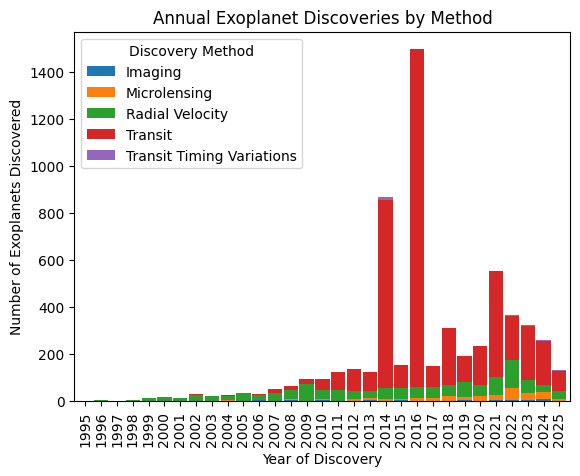

In [8]:
# Discoveries overtime organized by top 5 discovery methods
top_methods = legend_df['Discovery Method'].value_counts().nlargest(5).index

top_df = legend_df[legend_df['Discovery Method'].isin(top_methods)]

pivot_discovery = top_df.groupby(['Discovery Year', 'Discovery Method']).size().unstack()
    # Pivoting is important in a stacked bar chart because I want to gather data on the NUMBER of ...
    # ... methods found, leading to my rows counting the discovery methods found vs listing of each time it was used
    # '.size()' Long list of counts of methods in a given year which are grouped together with the year
    # '.unstack()' Separates groups into separate columns for Year and Methods needed for bar chart order

ax = pivot_discovery.plot(
    kind = 'bar',
    stacked = 'True',
    width = 0.9
)

plt.title('Annual Exoplanet Discoveries by Method')
plt.xlabel('Year of Discovery')
plt.ylabel('Number of Exoplanets Discovered')
plt.show()

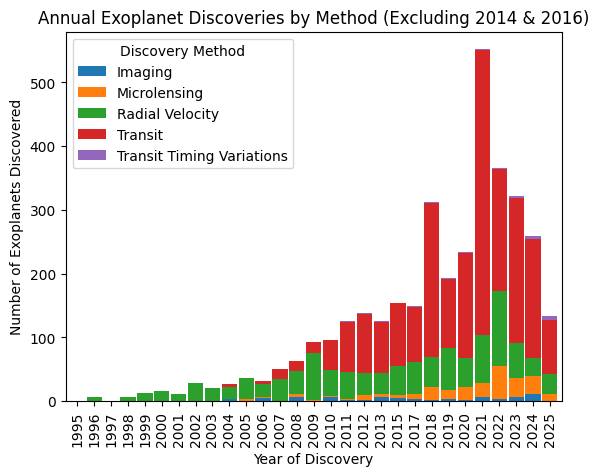

In [9]:
# Removing years 2014 and 2016 due to skewing graph
filtered_df = top_df[~top_df['Discovery Year'].isin([2014, 2016])]

filtered_pivot_discovery = filtered_df.groupby(['Discovery Year', 'Discovery Method']).size().unstack()

ax = filtered_pivot_discovery.plot(
    kind = 'bar',
    stacked = 'True',
    width = 0.9
)

plt.title('Annual Exoplanet Discoveries by Method (Excluding 2014 & 2016)')
plt.xlabel('Year of Discovery')
plt.ylabel('Number of Exoplanets Discovered')
plt.show()

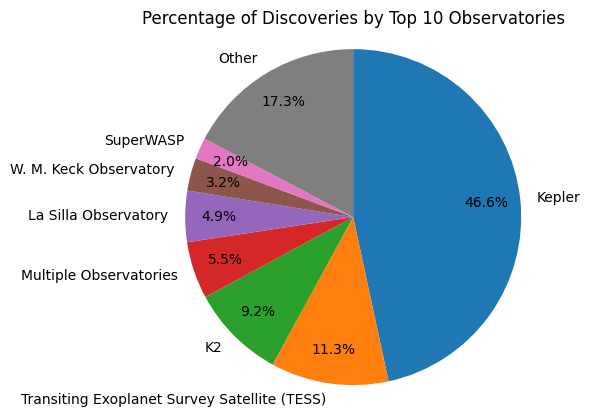

In [10]:
# Leading observatories using pie chart

observatory_counts = legend_df['Discovery Facility'].value_counts()

top_observatories = observatory_counts.nlargest(7)

other_observatories = observatory_counts.nsmallest(len(observatory_counts)- 7).sum()

top_observatories['Other'] = other_observatories

plt.pie(
    top_observatories.values,
    labels = top_observatories.index,
    startangle = 90,
    counterclock = False,
    autopct = '%1.1f%%',
    pctdistance = 0.8
)

plt.title('Percentage of Discoveries by Top 10 Observatories')
plt.axis('equal')
plt.show()

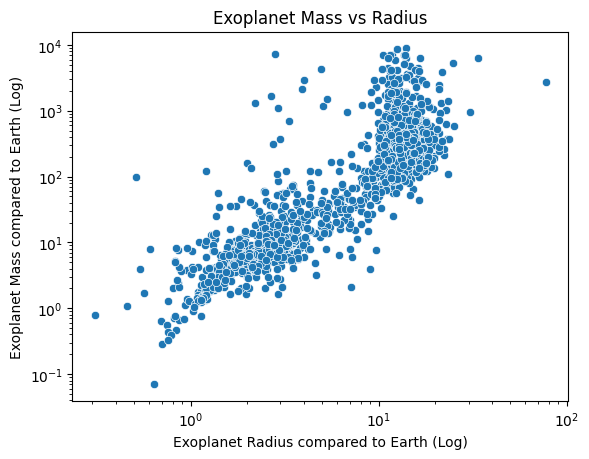

In [11]:
# Mass or Mass*sin(i) vs Radius [Earth]
ax = sns.scatterplot(
    data = legend_df,
    x = 'Planet Radius [Earth Radius]',
    y = 'Planet Mass or Mass*sin(i) [Earth Mass]'
)

ax.set_xscale('log')
ax.set_yscale('log')
    # When dealing with drastically large and drastically small values, using a logarithmic scale *********___

plt.title('Exoplanet Mass vs Radius')
plt.xlabel('Exoplanet Radius compared to Earth (Log)')
plt.ylabel('Exoplanet Mass compared to Earth (Log)')
plt.show()

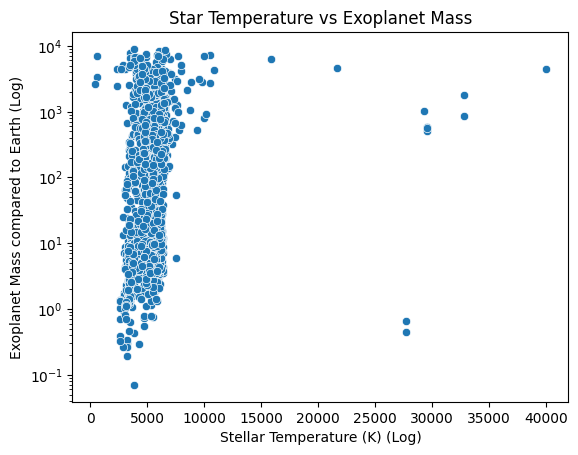

In [12]:
# Star temperature vs Planet radius
ax = sns.scatterplot(
    data = legend_df,
    x = 'Stellar Effective Temperature [K]',
    y = 'Planet Mass or Mass*sin(i) [Earth Mass]'
)

ax.set_yscale('log')
    # Only necessary for yaxis since temperature only varies several thousand K vs comparing masses between small and large planets

plt.title('Star Temperature vs Exoplanet Mass')
plt.xlabel('Stellar Temperature (K) (Log)')
plt.ylabel('Exoplanet Mass compared to Earth (Log)')
plt.show()

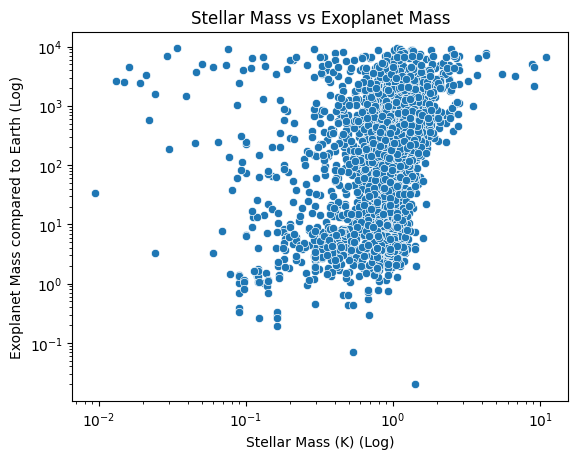

In [13]:
# Star mass vs Planet mass
ax = sns.scatterplot(
    data = legend_df,
    x = 'Stellar Mass [Solar mass]',
    y = 'Planet Mass or Mass*sin(i) [Earth Mass]'
)

ax.set_xscale('log')
ax.set_yscale('log')

plt.title('Stellar Mass vs Exoplanet Mass')
plt.xlabel('Stellar Mass (K) (Log)')
plt.ylabel('Exoplanet Mass compared to Earth (Log)')
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


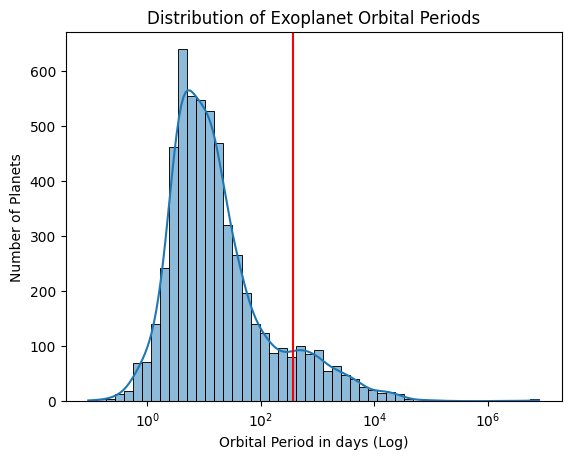

In [14]:
# Orbital period distribution, logarithmic
ax = sns.histplot(
    data = legend_df,
    x = 'Orbital Period [days]',
    log_scale = True,
    kde = True,
    bins = 50
)

plt.axvline(x = 365, color = 'red', label = 'Earth 365 days')

plt.title('Distribution of Exoplanet Orbital Periods')
plt.xlabel('Orbital Period in days (Log)')
plt.ylabel('Number of Planets')
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


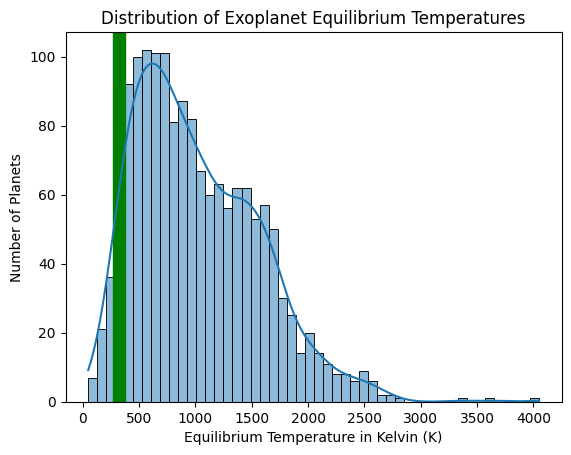

In [15]:
# Planet temperature distribution
ax = sns.histplot(
    data = legend_df,
    x = 'Equilibrium Temperature [K]',
    kde = True,
    bins = 50
)

plt.axvspan(273, 373, color = 'green', label = 'Liquid Water Range (0-100°C')

plt.title('Distribution of Exoplanet Equilibrium Temperatures')
plt.xlabel('Equilibrium Temperature in Kelvin (K)')
plt.ylabel('Number of Planets')
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


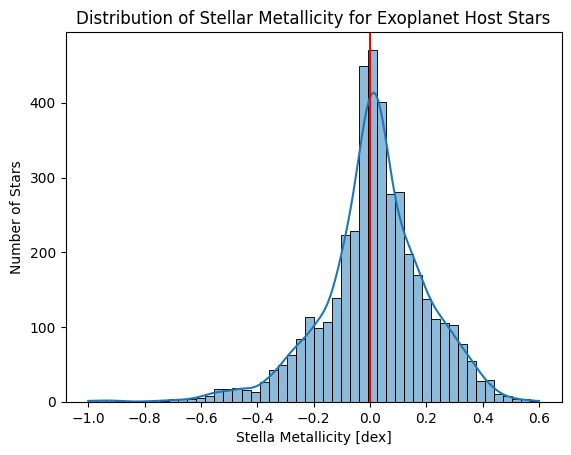

In [16]:
# Stellar Metallicity
ax = sns.histplot(
    data = legend_df,
    x = 'Stellar Metallicity [dex]',
    kde = True,
    bins = 50
)

plt.axvline(x = 0, color = 'red', label = "Sun's metallicity")

plt.title('Distribution of Stellar Metallicity for Exoplanet Host Stars')
plt. xlabel('Stella Metallicity [dex]')
plt.ylabel('Number of Stars')
plt.show()

## Habital Zone Plot

/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater_equal
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less_equal
  return op(a, b)


Original number of planets: 
5972
 
Number of planets after filtering outliers: 
5041


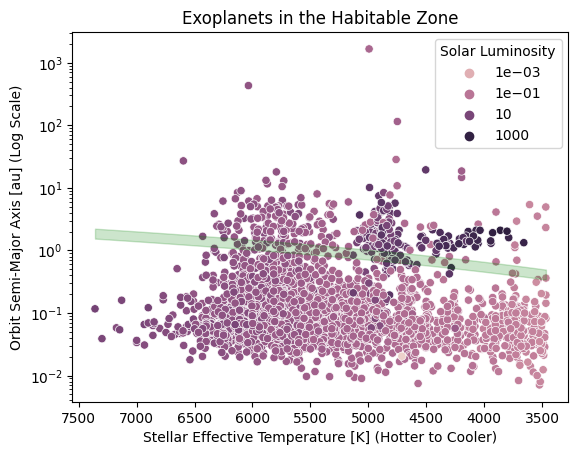

In [17]:
# Habital Zone Plot
# Stellar Temperature vs Exoplanet Orbital Distance
hzp_df = legend_df.copy()

sun_temp = 5780
    # Our sun's temperature in Kelvin
hzp_df['Solar Luminosity'] = hzp_df['Stellar Radius [Solar Radius]'] ** 2 * (hzp_df['Stellar Effective Temperature [K]'] / sun_temp) ** 4
    # Stefan-Boltzmann law for Luminocity: L = (solar radius^2) * (stellar temp^4)

# Set interquartile ranges to remove outliers in a large data set
Q1 = hzp_df['Stellar Effective Temperature [K]'].quantile(0.25)
Q3 = hzp_df['Stellar Effective Temperature [K]'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Removes outliers based on Stellar temp
filtered_hzp_df = hzp_df[(hzp_df['Stellar Effective Temperature [K]'] >= lower) & (hzp_df['Stellar Effective Temperature [K]'] <= upper)].copy()

# Lists effect of removing outliers
print(f"Original number of planets: \n{len(hzp_df)}\n \nNumber of planets after filtering outliers: \n{len(filtered_hzp_df)}")

ax = sns.scatterplot(
    data = filtered_hzp_df,
    x = 'Stellar Effective Temperature [K]',
    y = 'Orbit Semi-Major Axis [au]',
    hue = 'Solar Luminosity',
    hue_norm = LogNorm()
)

# Creates the habitable zone range that will be drawn later
temp_range = np.linspace(
    filtered_hzp_df['Stellar Effective Temperature [K]'].min(), 
    filtered_hzp_df['Stellar Effective Temperature [K]'].max(),
    500
)
    # Important for creating a smooth space of temperature with 500 range 

# Estimate a typical luminosity for each temperature for use in habitable zone area
lum_range = (temp_range / sun_temp)**4 
    # '4' just incorporates the temperature from the Stefan-Boltzmann law as radius is estimated to be 1 (same radius as Sun)

# Calculate habitable zone boundaries with smooth luminosity curve
hz_inner_smooth = np.sqrt(lum_range / 1.1)
hz_outer_smooth = np.sqrt(lum_range / 0.53)
    # '1.1' Runaway Greenhouse Limit: Maximum solar energy so the planet does not loose water
    # '0.53' Maxium Greenhouse Limit: Minimum solar energy so surface water does not freeze

# Draws habitable zone area
plt.fill_between(
    temp_range, 
    hz_inner_smooth, 
    hz_outer_smooth, 
    alpha = 0.2,
    label = 'Habitable Zone',
    color = 'green'
)

ax.set_yscale('log')
ax.invert_xaxis()

plt.title('Exoplanets in the Habitable Zone')
plt.xlabel('Stellar Effective Temperature [K] (Hotter to Cooler)')
plt.ylabel('Orbit Semi-Major Axis [au] (Log Scale)')
plt.show()